In [79]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Reshape, Dropout, BatchNormalization as BN, GaussianNoise as GN
from keras.regularizers import L2
from tensorflow.keras.optimizers import SGD, Adam
from keras.utils.np_utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.preprocessing.image import ImageDataGenerator
import os

from keras.callbacks import LearningRateScheduler as LRS, ReduceLROnPlateau
import matplotlib.pyplot as plt

In [80]:
BATCH_SIZE = 128
EPOCHS = 65
NUM_CLASSES=10
DECAY = decay=0.005
INITIAL_LR=0.01

In [81]:
def load_data():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    x_train = x_train.reshape(60000, 28,28,1)
    x_test = x_test.reshape(10000, 28,28,1)

    x_train = x_train.astype('float32')
    x_test = x_test.astype('float32')

    return x_train, y_train, x_test, y_test

In [82]:
def normalize_data(data):
    return data / 255

In [83]:
def vectorize_classes(y_tr, y_te):
    y_train = to_categorical(y_tr, NUM_CLASSES)
    y_test = to_categorical(y_te, NUM_CLASSES)
    return y_train, y_test

In [84]:
checkpoint_path = "training/mnist.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = ModelCheckpoint(filepath=checkpoint_path,
                                            save_weights_only=True,
                                            verbose=1)
def define_topology():
    model = Sequential()

    model.add(Reshape(target_shape=(784,), input_shape=(28,28,1)))
    
    model.add(Dense(1024))
    model.add(BN())
    model.add(GN(0.1))
    model.add(Activation('relu'))

    model.add(Dense(1024))
    model.add(BN())
    model.add(GN(0.2))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(Dense(1024))
    model.add(BN())
    model.add(GN(0.25))
    model.add(Activation('relu'))
    model.add(Dropout(0.15))

    model.add(Dense(1024))
    model.add(BN())
    model.add(GN(0.3))
    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Dense(NUM_CLASSES))
    model.add(Activation('softmax'))

    model.summary()
    return model

In [85]:
def define_optimizer():
    #sgd=SGD(learning_rate=0.01, momentum=0.9)
    adam = Adam(learning_rate=0.001)
    return adam

In [86]:
def learning_rate_annealing(current_epoch):
    return INITIAL_LR * (1 / (1 + DECAY * current_epoch))

In [87]:
def compile_model(model, opt):
    model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])
    return model

In [88]:
def train_model(model, x_tr, y_tr, x_te, y_te):
    #lr_sch = LRS(learning_rate_annealing)
    lr_sch = ReduceLROnPlateau(monitor='val_loss', patience=5)
    datagen = ImageDataGenerator(
      width_shift_range=0.15,
      height_shift_range=0.15,
      horizontal_flip=False)
    history = model.fit(datagen.flow(x_tr, y_tr, batch_size=BATCH_SIZE),
                    epochs=EPOCHS,
                    verbose=1,
                    validation_data=(x_te, y_te),
                    callbacks=[lr_sch, cp_callback])
    return model, history

In [89]:
def eval_model(model, x_te, y_te):
    score = model.evaluate(x_te, y_te, verbose=0)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])

In [90]:
def plot_evolution(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig('')

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_6 (Reshape)         (None, 784)               0         
                                                                 
 dense_30 (Dense)            (None, 1024)              803840    
                                                                 
 batch_normalization_24 (Bat  (None, 1024)             4096      
 chNormalization)                                                
                                                                 
 gaussian_noise_24 (Gaussian  (None, 1024)             0         
 Noise)                                                          
                                                                 
 activation_30 (Activation)  (None, 1024)              0         
                                                                 
 dense_31 (Dense)            (None, 1024)             

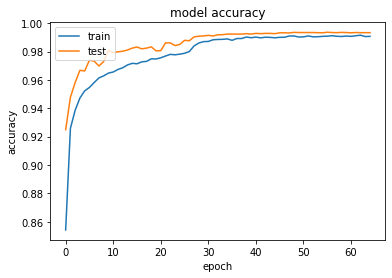

In [91]:
x_tr, y_tr, x_te, y_te = load_data()
    
x_tr = normalize_data(x_tr)
x_te = normalize_data(x_te)

y_tr, y_te = vectorize_classes(y_tr, y_te)

model = define_topology()
opt = define_optimizer()

model = compile_model(model, opt)
model, history = train_model(model, x_tr, y_tr, x_te, y_te)

plot_evolution(history)

eval_model(model, x_te, y_te)